# Café Reviews — Descriptive Analysis

**Project:** Customer Experience Analysis — Bengaluru Cafés  
**Cafés:** Beanlore · Isobel Coffee House · Third Wave Coffee  
**Dataset:** `../data/processed/reviews_master.csv`

---

This notebook answers: **"What is happening in the data?"**

It describes review volume, reviewer profiles, and café performance using tables and charts.  
No hypothesis testing, regression, or predictive modelling is included here.

## Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

CAFE_ORDER = ["Beanlore", "Isobel Coffee House", "Third Wave Coffee"]

df = pd.read_csv("../data/processed/reviews_master.csv")
df["published_at"] = pd.to_datetime(df["published_at"], utc=True, format="mixed")
df["review_month"] = df["published_at"].dt.to_period("M").astype(str)

print(f"Loaded {len(df):,} reviews across {df['cafe'].nunique()} cafés.")

Loaded 2,308 reviews across 3 cafés.


---
# Executive Summary

A high-level comparison of the three cafés across review volume and average ratings.

In [ ]:
executive = df.groupby("cafe").agg(
    total_reviews=("rating", "count"),
    avg_rating=("rating", "mean"),
    avg_atmosphere=("atmosphere", "mean"),
    avg_service=("service", "mean"),
    avg_food=("food_rating", "mean"),
).reindex(CAFE_ORDER).round(2)

executive.columns = [
    "Total Reviews",
    "Average Rating",
    "Average Atmosphere Rating",
    "Average Service Rating",
    "Average Food Rating",
]

display(executive)
executive.to_csv("../outputs/tables/executive_summary.csv", index=True)

,Total Reviews,Average Rating,Average Atmosphere Rating,Average Service Rating,Average Food Rating
cafe,,,,,
Beanlore,308,4.00,4.43,3.90,4.10
Isobel Coffee House,1000,4.44,4.59,4.50,4.44
Third Wave Coffee,1000,4.41,4.44,4.36,4.32


---
# Section 1 — Dataset Overview

Understand the size, time coverage, and review activity in the dataset.

## Analysis 1 — Reviews per Café

How many reviews does each café contribute to the dataset?

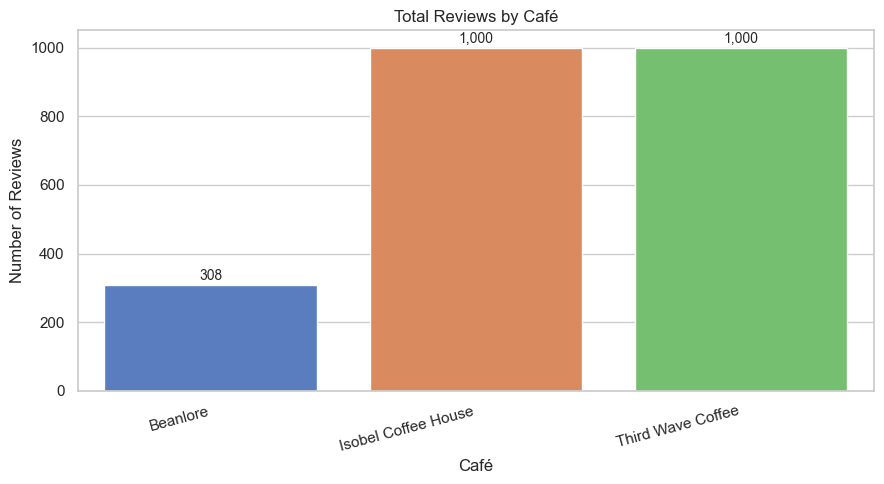

In [ ]:
cafe_counts = df["cafe"].value_counts().reindex(CAFE_ORDER)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=cafe_counts.index, y=cafe_counts.values, ax=ax, palette="muted")
ax.set_title("Total Reviews by Café")
ax.set_xlabel("Café")
ax.set_ylabel("Number of Reviews")
for i, v in enumerate(cafe_counts.values):
    ax.text(i, v + 15, f"{v:,}", ha="center", fontsize=10)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/01_reviews_per_cafe.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** Isobel Coffee House and Third Wave Coffee each contribute 1,000 reviews, while Beanlore contributes 308 reviews.


## Analysis 2 — Dataset Date Range

When were reviews first and most recently published?

In [ ]:
earliest = df["published_at"].min()
latest = df["published_at"].max()
timespan_days = (latest - earliest).days

date_summary = pd.DataFrame({
    "Metric": ["Earliest Review", "Latest Review", "Total Timespan (days)"],
    "Value": [
        earliest.strftime("%Y-%m-%d"),
        latest.strftime("%Y-%m-%d"),
        f"{timespan_days:,}",
    ],
})

display(date_summary)
date_summary.to_csv("../outputs/tables/dataset_date_range.csv", index=False)

,Metric,Value
0,Earliest Review,2021-07-02
1,Latest Review,2026-06-01
2,Total Timespan (days),"1,794"


**Interpretation:** The dataset encompasses reviews published from July 2021 to June 2026, representing a total span of approximately 1,794 days.


## Analysis 4 — Monthly Review Volume by Café

How does monthly review activity differ across the three cafés over time?

In [ ]:
monthly_cafe = df.groupby(["review_month", "cafe"]).size().reset_index(name="review_count")
monthly_cafe["cafe"] = pd.Categorical(monthly_cafe["cafe"], categories=CAFE_ORDER, ordered=True)
monthly_cafe = monthly_cafe.sort_values("review_month")

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=monthly_cafe,
    x="review_month",
    y="review_count",
    hue="cafe",
    hue_order=CAFE_ORDER,
    marker="o",
    markersize=5,
    linewidth=1.8,
    ax=ax,
    palette="muted",
)
ax.set_title("Monthly Review Volume by Café")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Reviews")
ax.legend(title="Café")

# Show fewer x-axis labels for readability
months = sorted(monthly_cafe["review_month"].unique())
tick_step = max(1, len(months) // 12)
ax.set_xticks(range(0, len(months), tick_step))
ax.set_xticklabels([months[i] for i in range(0, len(months), tick_step)], rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/02_monthly_review_volume.png", dpi=300, bbox_inches="tight")
plt.show()

# Peak month summary per café
peak_rows = []
for cafe in CAFE_ORDER:
    cafe_data = monthly_cafe[monthly_cafe["cafe"] == cafe]
    peak_row = cafe_data.loc[cafe_data["review_count"].idxmax()]
    peak_rows.append({
        "Café": cafe,
        "Total Reviews": len(df[df["cafe"] == cafe]),
        "Peak Month": peak_row["review_month"],
        "Peak Review Count": int(peak_row["review_count"]),
    })

peak_summary = pd.DataFrame(peak_rows)
print("Monthly review volume summary by café:")
display(peak_summary)
peak_summary.to_csv("../outputs/tables/monthly_review_volume.csv", index=False)


**Interpretation:** Isobel Coffee House reached its peak monthly review count in August 2023 with 189 reviews, whereas Beanlore's review volume is concentrated primarily in more recent months such as May 2026. Third Wave Coffee exhibits a relatively consistent distribution of reviews over time.


---
# Section 2 — Reviewer Profile Analysis

Understand who is writing the reviews and how reviewer type varies across cafés.

## Analysis 5 — Local Guide vs Non-Local Guide Distribution

What share of reviews at each café comes from Google Local Guides?

In [ ]:
if "is_local_guide" in df.columns:
    lg_counts = df.groupby(["cafe", "is_local_guide"]).size().unstack(fill_value=0)
    lg_counts = lg_counts.reindex(CAFE_ORDER)
    lg_counts.columns = ["Non-Local Guide", "Local Guide"]

    lg_pct = (lg_counts.div(lg_counts.sum(axis=1), axis=0) * 100).round(1)
    print("Local Guide share by café (%):")
    display(lg_pct[["Local Guide"]].rename(columns={"Local Guide": "Local Guide %"}))
    lg_pct.to_csv("../outputs/tables/local_guide_share.csv", index=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    lg_counts.plot(kind="bar", stacked=True, ax=ax, color=["#aec6cf", "#779ecb"])
    ax.set_title("Local Guide vs Non-Local Guide Reviews by Café")
    ax.set_xlabel("Café")
    ax.set_ylabel("Number of Reviews")
    ax.legend(title="Reviewer Type")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig("../outputs/figures/03_local_guide_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Column 'is_local_guide' not found.")


**Interpretation:** Google Local Guides contribute the majority of reviews at Third Wave Coffee with a share of 55.3%, whereas they account for 44.8% of reviews at Beanlore and 33.8% at Isobel Coffee House.


## Analysis 6 — Average Rating by Local Guide Status and Café

Do Local Guides rate each café differently than Non-Local Guide reviewers?

In [ ]:
if "is_local_guide" in df.columns:
    lg_cafe_rating = df.groupby(["cafe", "is_local_guide"])["rating"].mean().unstack().round(2)
    lg_cafe_rating = lg_cafe_rating.reindex(CAFE_ORDER)
    lg_cafe_rating.columns = ["Non-Local Guide Avg Rating", "Local Guide Avg Rating"]

    print("Average rating by café and reviewer type:")
    display(lg_cafe_rating)
    lg_cafe_rating.to_csv("../outputs/tables/rating_by_local_guide.csv", index=True)

    lg_cafe_plot = lg_cafe_rating.reset_index().melt(
        id_vars="cafe", var_name="Reviewer Type", value_name="Average Rating"
    )
    lg_cafe_plot["Reviewer Type"] = lg_cafe_plot["Reviewer Type"].map({
        "Non-Local Guide Avg Rating": "Non-Local Guide",
        "Local Guide Avg Rating": "Local Guide",
    })

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=lg_cafe_plot,
        x="cafe",
        y="Average Rating",
        hue="Reviewer Type",
        order=CAFE_ORDER,
        ax=ax,
        palette="muted",
    )
    ax.set_title("Average Rating by Local Guide Status and Café")
    ax.set_xlabel("Café")
    ax.set_ylabel("Average Rating")
    ax.set_ylim(3.5, 5)
    ax.legend(title="Reviewer Type")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig("../outputs/figures/04_rating_by_local_guide.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Column 'is_local_guide' not found.")


**Interpretation:** At all three cafés, Local Guide reviewers assign lower average ratings than Non-Local Guides. For Beanlore, Local Guides record an average rating of 3.80 compared to 4.16 from Non-Local Guides, while the difference is also visible at Isobel Coffee House (4.16 vs 4.59) and Third Wave Coffee (4.16 vs 4.72).


## Analysis 7 — Average Local Guide Level by Café

Among Local Guide reviewers, how experienced are they at each café?

In [ ]:
if "local_guide_level" in df.columns:
    lg_level = df.groupby("cafe")["local_guide_level"].mean().reindex(CAFE_ORDER).round(2)
    lg_level.to_csv("../outputs/tables/local_guide_level.csv", index=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(x=lg_level.index, y=lg_level.values, ax=ax, palette="muted")
    ax.set_title("Average Local Guide Level by Café")
    ax.set_xlabel("Café")
    ax.set_ylabel("Average Local Guide Level")
    for i, v in enumerate(lg_level.values):
        ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig("../outputs/figures/05_local_guide_level.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Column 'local_guide_level' not found.")


**Interpretation:** Among Local Guide reviewers, Third Wave Coffee attracts those with the highest average experience level of 4.24, compared to average levels of 3.61 for Beanlore and 3.42 for Isobel Coffee House.


## Analysis 8 — Average Reviewer Review Count by Café

How active are reviewers at each café, based on their total Google review history?

In [ ]:
if "author_review_count" in df.columns:
    author_count = df.groupby("cafe")["author_review_count"].mean().reindex(CAFE_ORDER).round(1)
    author_count.to_csv("../outputs/tables/reviewer_review_count.csv", index=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(x=author_count.index, y=author_count.values, ax=ax, palette="muted")
    ax.set_title("Average Reviewer Review Count by Café")
    ax.set_xlabel("Café")
    ax.set_ylabel("Average Author Review Count")
    for i, v in enumerate(author_count.values):
        ax.text(i, v + 1, f"{v:.1f}", ha="center", fontsize=10)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig("../outputs/figures/06_reviewer_review_count.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Column 'author_review_count' not found.")


**Interpretation:** Reviewers at Third Wave Coffee are the most active on Google Maps, with an average of 59.3 prior reviews per author, compared to averages of 32.7 for Beanlore and 28.4 for Isobel Coffee House.


---
# Section 3 — Overall Performance Analysis

Compare each café's ratings across overall satisfaction and the three experience dimensions: atmosphere, service, and food.

## Analysis 9 — Average Overall Rating by Café

In [ ]:
avg_rating = df.groupby("cafe")["rating"].mean().reindex(CAFE_ORDER).round(2)
avg_rating.to_csv("../outputs/tables/overall_rating_by_cafe.csv", index=True)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=avg_rating.index, y=avg_rating.values, ax=ax, palette="muted")
ax.set_title("Average Overall Rating by Café")
ax.set_xlabel("Café")
ax.set_ylabel("Average Rating")
ax.set_ylim(3.5, 5)
for i, v in enumerate(avg_rating.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/07_overall_rating_by_cafe.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation:** Isobel Coffee House achieves the highest average overall rating of 4.44, closely followed by Third Wave Coffee at 4.41, while Beanlore records the lowest average overall rating of 4.00.


## Rating Distribution by Café

Average ratings can hide differences in how reviews are spread across star levels.  
This analysis shows the full 1–5 star distribution for each café.

In [ ]:
rating_pct_rows = []
for cafe in CAFE_ORDER:
    cafe_ratings = df[df["cafe"] == cafe]["rating"]
    counts = cafe_ratings.value_counts().sort_index()
    pcts = (counts / len(cafe_ratings) * 100).round(1)
    for star, pct in pcts.items():
        rating_pct_rows.append({"Café": cafe, "Rating": int(star), "Count": counts[star], "Percentage": pct})

rating_dist = pd.DataFrame(rating_pct_rows)
rating_pivot = rating_dist.pivot(index="Café", columns="Rating", values="Percentage").reindex(CAFE_ORDER)
rating_pivot.columns = [f"{int(c)}-Star %" for c in rating_pivot.columns]

print("Rating distribution by café (% of reviews):")
display(rating_pivot)
rating_pivot.to_csv("../outputs/tables/rating_distribution_pivot.csv", index=True)

# Combined comparison across all cafés
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x="rating", hue="cafe", hue_order=CAFE_ORDER, ax=ax, palette="muted")
ax.set_title("Rating Distribution by Café")
ax.set_xlabel("Rating (stars)")
ax.set_ylabel("Number of Reviews")
ax.legend(title="Café")
plt.tight_layout()
plt.savefig("../outputs/figures/08_rating_distribution_combined.png", dpi=300, bbox_inches="tight")
plt.show()

# Separate subplot for each café
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, cafe in zip(axes, CAFE_ORDER):
    cafe_df = df[df["cafe"] == cafe]
    sns.countplot(data=cafe_df, x="rating", order=[1, 2, 3, 4, 5], ax=ax, color="steelblue")
    ax.set_title(cafe)
    ax.set_xlabel("Rating (stars)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("../outputs/figures/09_rating_distribution_by_cafe.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation:** Isobel Coffee House displays the highest concentration of 5-star reviews at 75.2%, whereas Beanlore records the largest share of 1-star reviews at 13.0%. Third Wave Coffee displays a stable rating distribution with 69.6% 5-star and 15.9% 4-star ratings.


## Analysis 10 — Average Atmosphere Rating by Café

In [ ]:
if "atmosphere" in df.columns:
    avg_atm = df.groupby("cafe")["atmosphere"].mean().reindex(CAFE_ORDER).round(2)
    avg_atm.to_csv("../outputs/tables/atmosphere_rating_by_cafe.csv", index=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(x=avg_atm.index, y=avg_atm.values, ax=ax, palette="muted")
    ax.set_title("Average Atmosphere Rating by Café")
    ax.set_xlabel("Café")
    ax.set_ylabel("Average Atmosphere Rating")
    ax.set_ylim(3.5, 5)
    for i, v in enumerate(avg_atm.values):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig("../outputs/figures/10_atmosphere_rating_by_cafe.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Column 'atmosphere' not found.")


**Interpretation:** Atmosphere ratings are consistently high across all three cafés, with Isobel Coffee House leading at an average of 4.59, followed by Third Wave Coffee at 4.44 and Beanlore at 4.43.


## Analysis 11 — Average Service Rating by Café

In [ ]:
if "service" in df.columns:
    avg_svc = df.groupby("cafe")["service"].mean().reindex(CAFE_ORDER).round(2)
    avg_svc.to_csv("../outputs/tables/service_rating_by_cafe.csv", index=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(x=avg_svc.index, y=avg_svc.values, ax=ax, palette="muted")
    ax.set_title("Average Service Rating by Café")
    ax.set_xlabel("Café")
    ax.set_ylabel("Average Service Rating")
    ax.set_ylim(3.5, 5)
    for i, v in enumerate(avg_svc.values):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig("../outputs/figures/11_service_rating_by_cafe.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Column 'service' not found.")


**Interpretation:** Service ratings differ notably across the cafés, with Isobel Coffee House obtaining the highest average of 4.50, followed by Third Wave Coffee at 4.36. Beanlore shows a distinct deficit in this area, recording a service average of 3.90, which is its lowest score across all experience dimensions.


## Analysis 12 — Average Food Rating by Café

In [ ]:
if "food_rating" in df.columns:
    avg_food = df.groupby("cafe")["food_rating"].mean().reindex(CAFE_ORDER).round(2)
    avg_food.to_csv("../outputs/tables/food_rating_by_cafe.csv", index=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(x=avg_food.index, y=avg_food.values, ax=ax, palette="muted")
    ax.set_title("Average Food Rating by Café")
    ax.set_xlabel("Café")
    ax.set_ylabel("Average Food Rating")
    ax.set_ylim(3.5, 5)
    for i, v in enumerate(avg_food.values):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig("../outputs/figures/12_food_rating_by_cafe.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Column 'food_rating' not found.")


**Interpretation:** Food ratings are highest at Isobel Coffee House with an average score of 4.44, while Third Wave Coffee and Beanlore show slightly lower averages of 4.32 and 4.10, respectively. These values suggest a generally positive reception of the food offerings across all three establishments.


## Analysis 13 — Combined Café Performance Comparison

A side-by-side view of overall rating, atmosphere, service, and food ratings across all three cafés.

In [ ]:
perf_cols = ["rating", "atmosphere", "service", "food_rating"]
available_perf = [c for c in perf_cols if c in df.columns]

if available_perf:
    perf = df.groupby("cafe")[available_perf].mean().reindex(CAFE_ORDER).round(2)
    perf_display = perf.rename(columns={
        "rating": "Overall Rating",
        "atmosphere": "Atmosphere",
        "service": "Service",
        "food_rating": "Food",
    })
    display(perf_display)
    perf_display.to_csv("../outputs/tables/combined_cafe_performance_summary.csv", index=True)

    perf_plot = perf_display.reset_index().melt(id_vars="cafe", var_name="dimension", value_name="avg_rating")

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=perf_plot,
        x="cafe",
        y="avg_rating",
        hue="dimension",
        hue_order=["Overall Rating", "Atmosphere", "Service", "Food"],
        order=CAFE_ORDER,
        ax=ax,
        palette="muted",
    )
    ax.set_title("Café Performance Comparison — Overall Rating, Atmosphere, Service & Food")
    ax.set_xlabel("Café")
    ax.set_ylabel("Average Rating")
    ax.set_ylim(3.5, 5)
    ax.legend(title="Dimension")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig("../outputs/figures/13_combined_cafe_performance.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Performance columns not found.")


**Interpretation:** Isobel Coffee House demonstrates the strongest performance across all evaluated dimensions, consistently achieving the highest average scores. Beanlore shows a notable underperformance in service, while Third Wave Coffee maintains strong and consistent ratings across atmosphere, service, and food.


---
# Section 4 — Rating Patterns

Understand how ratings are distributed beyond simple averages, including spread, variability, and coverage of sub-ratings.

## Analysis 14 — Rating Variability by Café

How much do overall ratings vary within each café, beyond just the average?

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="rating", y="cafe", order=CAFE_ORDER, ax=ax, palette="muted")
ax.set_title("Overall Rating Distribution by Café")
ax.set_xlabel("Overall Rating")
ax.set_ylabel("Café")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/14_overall_rating_variability.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation:** Beanlore displays a wider dispersion of overall ratings, with its interquartile range spanning from 3.0 to 5.0. In contrast, Isobel Coffee House shows the highest concentration of ratings, with more than 75% of reviews scoring the maximum of 5.0 stars, while Third Wave Coffee's middle 50% ranges from 4.0 to 5.0 stars.


## Analysis 15 — Atmosphere Rating Distribution by Café
How much do atmosphere ratings vary within each café?

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="atmosphere", y="cafe", order=CAFE_ORDER, ax=ax, palette="muted")
ax.set_title("Atmosphere Rating Distribution by Café")
ax.set_xlabel("Atmosphere Rating")
ax.set_ylabel("Café")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/15_atmosphere_rating_variability.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation:** Atmosphere ratings are consistently high across all three cafés, with each showing a median of 5.0. Beanlore and Third Wave Coffee have interquartile ranges from 4.0 to 5.0, while Isobel Coffee House exhibits even less variation, with over 75% of reviews scoring 5.0 stars.


## Analysis 16 — Service Rating Distribution by Café
How much do service ratings vary within each café?

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="service", y="cafe", order=CAFE_ORDER, ax=ax, palette="muted")
ax.set_title("Service Rating Distribution by Café")
ax.set_xlabel("Service Rating")
ax.set_ylabel("Café")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/16_service_rating_variability.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation:** Service ratings for Beanlore are widely distributed, with the interquartile range spanning from 3.0 to 5.0, reflecting more variable performance compared to other dimensions. In contrast, Third Wave Coffee and Isobel Coffee House show a high concentration of service ratings near the top of the scale, with lower quartiles of 4.0 and 5.0, respectively.


## Analysis 17 — Food Rating Distribution by Café
How much do food ratings vary within each café?

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="food_rating", y="cafe", order=CAFE_ORDER, ax=ax, palette="muted")
ax.set_title("Food Rating Distribution by Café")
ax.set_xlabel("Food Rating")
ax.set_ylabel("Café")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/17_food_rating_variability.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation:** Food ratings show similar distributions across all three establishments, with each café recording a median rating of 5.0 and an interquartile range from 4.0 to 5.0. While Beanlore's mean food rating is slightly lower at 4.10, all three cafés exhibit outliers extending down to 1.0 star.


## Analysis 18 — Sub-Rating Coverage
What proportion of reviews include atmosphere, service, and food ratings? This indicates how reliable the sub-dimension averages are.

In [ ]:
sub_rating_cols = ["atmosphere", "service", "food_rating"]

coverage_table = pd.DataFrame({
    "Sub-Rating": sub_rating_cols,
    "Non-Null Count": [df[col].notna().sum() for col in sub_rating_cols],
    "Coverage (%)": [round(df[col].notna().mean() * 100, 2) for col in sub_rating_cols],
}).set_index("Sub-Rating")

display(coverage_table)
coverage_table.to_csv("../outputs/tables/sub_rating_coverage.csv", index=True)


**Interpretation:** Approximately two-thirds of the reviews in the dataset include experience sub-ratings, with coverage percentages of 66.51% for atmosphere, 67.33% for service, and 66.25% for food. This consistent coverage across all three dimensions ensures that the averages are based on a large and robust subset of customer feedback.


---
# Section 5 — Driver Analysis

Explore the relationships between overall rating and the three experience dimensions: atmosphere, service, and food.

## Analysis 19 — Correlation Matrix
Measures how strongly overall rating, atmosphere, service, and food rating relate to one another

In [ ]:
corr_cols = ["rating", "atmosphere", "service", "food_rating"]
corr_matrix = df[corr_cols].corr().round(2)

print("Correlation matrix:")
display(corr_matrix)
corr_matrix.to_csv("../outputs/tables/correlation_matrix.csv", index=True)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
ax.set_title("Correlation Matrix — Overall Rating vs Experience Dimensions")
plt.tight_layout()
plt.savefig("../outputs/figures/18_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation:** Strong positive correlations are observed between all three experience dimensions and overall rating, with service having the highest correlation coefficient of 0.89, followed closely by food at 0.87. Atmosphere displays a slightly weaker but still strong correlation with overall rating at 0.78, while the inter-dimension correlation is highest between service and food at 0.78.


## Analysis 20 — Overall Rating vs Experience Dimensions
How do atmosphere, service, and food ratings relate to overall rating, shown together for comparison?

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

dimensions = [
    ("atmosphere", "Atmosphere Rating", "steelblue"),
    ("service", "Service Rating", "darkorange"),
    ("food_rating", "Food Rating", "seagreen"),
]

for ax, (col, label, color) in zip(axes, dimensions):
    sns.regplot(data=df, x=col, y="rating", scatter_kws={"alpha": 0.3}, color=color, ax=ax)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Overall Rating" if ax == axes[0] else "")

plt.tight_layout()
plt.savefig("../outputs/figures/19_overall_vs_dimensions_regplot.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation:** Scatter plots with superimposed regression lines demonstrate a positive linear relationship between each of the three experience dimensions and overall rating. Higher scores in atmosphere, service, and food ratings consistently map to higher overall customer satisfaction ratings, as indicated by the positive slope of all three regression lines.


## Analysis 21 — Average Dimension Scores by Overall Rating
For each overall rating level (1-5 stars), what are the average atmosphere, service, and food scores?

In [ ]:
dimension_by_rating = df.groupby("rating")[["atmosphere", "service", "food_rating"]].mean().round(2)

print("Average dimension scores by overall rating:")
display(dimension_by_rating)
dimension_by_rating.to_csv("../outputs/tables/avg_dimension_scores_by_overall_rating.csv", index=True)

fig, ax = plt.subplots(figsize=(9, 5))
for col, label in zip(["atmosphere", "service", "food_rating"], ["Atmosphere", "Service", "Food"]): 
    ax.plot(dimension_by_rating.index, dimension_by_rating[col], marker="o", label=label)

ax.set_title("Average Dimension Scores by Overall Rating")
ax.set_xlabel("Overall Rating (Stars)")
ax.set_ylabel("Average Dimension Score")
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/20_avg_dimension_scores_by_overall_rating.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation:** Average scores for atmosphere, service, and food increase monotonically across overall rating levels from 1 to 5 stars. For reviews with a 1-star overall rating, average service and food scores are particularly low at 1.28 and 1.51, respectively, while for 5-star reviews, all three dimensions converge near the maximum score of 5.0.


## Analysis 22 — Café Strengths and Weaknesses
For each café, which experience dimension scores highest and which scores lowest?

In [ ]:
strengths_table = df.groupby("cafe")[["rating", "atmosphere", "service", "food_rating"]].mean().reindex(CAFE_ORDER).round(2)
strengths_table.columns = ["Overall Rating", "Atmosphere", "Service", "Food"]

dimension_cols = ["Atmosphere", "Service", "Food"]
strengths_table["Highest Dimension"] = strengths_table[dimension_cols].idxmax(axis=1)
strengths_table["Lowest Dimension"] = strengths_table[dimension_cols].idxmin(axis=1)

print("Café strengths and weaknesses summary:")
display(strengths_table)
strengths_table.to_csv("../outputs/tables/cafe_strengths_weaknesses.csv", index=True)


**Interpretation:** Atmosphere is the highest-scoring dimension across all cafés, particularly at Isobel Coffee House (4.59). Beanlore's lowest-scoring dimension is service (3.90), while Third Wave Coffee and Isobel Coffee House both show food as their lowest-rated dimension with averages of 4.32 and 4.44 respectively.


---
# Section 6 — Time Trends

Examine how ratings and review volume change over time for each café. To ensure reliable monthly averages, café-months with fewer than 10 reviews are excluded from rating trend calculations (but not from volume calculations).

## Preparing Filtered Monthly Data
Identify café-month combinations with at least 10 reviews, and use this filtered set for all rating trend analyses in this section.

In [ ]:
monthly_counts = df.groupby(["cafe", "review_month"]).size().reset_index(name="review_count")

valid_combinations = monthly_counts[monthly_counts["review_count"] >= 10][["cafe", "review_month"]]

df_filtered = df.merge(valid_combinations, on=["cafe", "review_month"], how="inner")

print(f"Original reviews: {len(df):,}")
print(f"Reviews after filtering to café-months with 10+ reviews: {len(df_filtered):,}")

Original reviews: 2,308
Reviews after filtering to café-months with 10+ reviews: 2,101


## Analysis 23 — Monthly Average Rating by Café
How does the average overall rating trend over time for each café?

In [ ]:
monthly_rating = df_filtered.groupby(["cafe", "review_month"])["rating"].mean().reset_index()
monthly_rating["cafe"] = pd.Categorical(monthly_rating["cafe"], categories=CAFE_ORDER, ordered=True)
monthly_rating = monthly_rating.sort_values("review_month")

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=monthly_rating,
    x="review_month",
    y="rating",
    hue="cafe",
    hue_order=CAFE_ORDER,
    marker="o",
    markersize=5,
    linewidth=1.8,
    ax=ax,
    palette="muted",
)
ax.set_title("Filtered Monthly Average Rating by Café")
ax.set_xlabel("Month")
ax.set_ylabel("Average Overall Rating")
ax.legend(title="Café")

# Show fewer x-axis labels for readability
months = sorted(monthly_rating["review_month"].unique())
tick_step = max(1, len(months) // 12)
ax.set_xticks(range(0, len(months), tick_step))
ax.set_xticklabels([months[i] for i in range(0, len(months), tick_step)], rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/21_monthly_average_rating_trend.png", dpi=300, bbox_inches="tight")
plt.show()
monthly_rating.to_csv("../outputs/tables/monthly_average_rating_trend.csv", index=False)


**Interpretation:** Filtered monthly average ratings over time display fluctuations for all three cafés, with Third Wave Coffee showing more stable average monthly scores compared to Isobel Coffee House. Beanlore's trend is only visible in the most recent months due to data density filtering, where its average ratings hover around the 4.0 mark.


## Analysis 24 — Monthly Experience Dimension Trends by Café
How do atmosphere, service, and food ratings trend over time for each café?

In [ ]:
dimensions = [
    ("atmosphere", "Atmosphere Rating", "steelblue"),
    ("service", "Service Rating", "darkorange"),
    ("food_rating", "Food Rating", "seagreen"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (col, label, color) in zip(axes, dimensions):
    monthly_dim = df_filtered.groupby(["cafe", "review_month"])[col].mean().reset_index()
    monthly_dim["cafe"] = pd.Categorical(monthly_dim["cafe"], categories=CAFE_ORDER, ordered=True)
    monthly_dim = monthly_dim.sort_values("review_month")
    
    sns.lineplot(
        data=monthly_dim,
        x="review_month",
        y=col,
        hue="cafe",
        hue_order=CAFE_ORDER,
        marker="o",
        markersize=5,
        linewidth=1.8,
        ax=ax,
        palette="muted",
    )
    ax.set_title(f"{label} Trend")
    ax.set_xlabel("Month")
    ax.set_ylabel(f"Average {label} Rating" if ax == axes[0] else "")
    
    # Show fewer x-axis labels
    months = sorted(monthly_dim["review_month"].unique())
    tick_step = max(1, len(months) // 12)
    ax.set_xticks(range(0, len(months), tick_step))
    ax.set_xticklabels([months[i] for i in range(0, len(months), tick_step)], rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../outputs/figures/22_monthly_dimension_trends_by_cafe.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation:** Monthly average rating trends show that atmosphere, service, and food fluctuate over time, with Third Wave Coffee exhibiting the most stable trajectories. Beanlore's trends are restricted to the final months of the dataset, where its service rating consistently remains below its atmosphere and food ratings.


---
# Section 7 — Price Analysis
Explore whether customer experience differs across price ranges.

In [ ]:
price_data = df.dropna(subset=["price_per_person"])

if len(price_data[price_data['cafe'] == 'Beanlore']) < 50:
    print("Insufficient data collected for Beanlore cafe for reliable analysis.")

if len(price_data[price_data['cafe'] == 'Third Wave Coffee']) < 50:
    print("Insufficient data collected for Thirdwave cafe for reliable analysis.")

    
if len(price_data[price_data['cafe'] == 'Isobel Coffee House']) < 50:
    print("Insufficient data collected for Isobel Coffee House for reliable analysis.")

## Analysis 31 — Price Range Distribution
How are reviews distributed across price ranges?

In [ ]:
price_data = df.dropna(subset=["price_per_person"])

price_counts = (
    price_data.groupby(["price_per_person", "cafe"])
    .size()
    .reset_index(name="review_count")
)
display(price_counts)
price_counts.to_csv("../outputs/tables/price_range_distribution.csv", index=False)

def price_sort_key(price_str):
    if not isinstance(price_str, str):
        return float("inf")
    cleaned = price_str.replace("₹", "").replace(",", "")
    for dash in ["–", "-"]:
        if dash in cleaned:
            parts = cleaned.split(dash)
            try:
                return float(parts[0])
            except ValueError:
                pass
    cleaned_digits = "".join([c for c in cleaned if c.isdigit()])
    if cleaned_digits:
        return float(cleaned_digits)
    return float("inf")

unique_prices = [p for p in price_data["price_per_person"].dropna().unique() if isinstance(p, str)]
price_order = sorted(unique_prices, key=price_sort_key)

price_counts["price_per_person"] = pd.Categorical(
    price_counts["price_per_person"],
    categories=price_order,
    ordered=True
)
price_counts = price_counts.sort_values("price_per_person")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=price_counts,
    x="price_per_person",
    y="review_count",
    hue="cafe",
    hue_order=CAFE_ORDER,
    palette="muted"
)

plt.title("Price Range Distribution by Café")
plt.xlabel("Price per Person")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Café")
plt.tight_layout()
plt.savefig("../outputs/figures/23_price_range_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
price_counts.to_csv("../outputs/tables/price_range_distribution.csv", index=False)


**Interpretation:** Reviews containing price information are highly concentrated in the ₹200–400 and ₹400–600 price ranges. For Beanlore and Isobel Coffee House, the most common price category is ₹400–600, whereas for Third Wave Coffee, the largest volume of reviews falls under the lower category of ₹200–400.


## Analysis 32 — Average Rating by Price Range
How does rating vary across price ranges within each cafe?

In [ ]:
def price_sort_key(price_str):
    if not isinstance(price_str, str):
        return float("inf")
    cleaned = price_str.replace("₹", "").replace(",", "")
    for dash in ["–", "-"]:
        if dash in cleaned:
            parts = cleaned.split(dash)
            try:
                return float(parts[0])
            except ValueError:
                pass
    cleaned_digits = "".join([c for c in cleaned if c.isdigit()])
    if cleaned_digits:
        return float(cleaned_digits)
    return float("inf")

unique_prices = [p for p in price_data["price_per_person"].dropna().unique() if isinstance(p, str)]
price_order = sorted(unique_prices, key=price_sort_key)

if len(price_data) >= 50:

    rating_by_price = (
        price_data
        .groupby(["price_per_person", "cafe"])["rating"]
        .mean()
        .reset_index()
    )

    rating_by_price["price_per_person"] = pd.Categorical(
        rating_by_price["price_per_person"],
        categories=price_order,
        ordered=True
    )

    rating_by_price = rating_by_price.sort_values("price_per_person")

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=rating_by_price,
        x="price_per_person",
        y="rating",
        hue="cafe",
        hue_order=CAFE_ORDER,
        palette="muted"
    )

    plt.title("Average Overall Rating by Price Range and Café")
    plt.xlabel("Price per Person")
    plt.ylabel("Average Overall Rating")
    plt.xticks(rotation=45)
    plt.legend(title="Café")
    plt.tight_layout()
    plt.savefig("../outputs/figures/24_average_rating_by_price_range.png", dpi=300, bbox_inches="tight")
    plt.show()
    rating_by_price.to_csv("../outputs/tables/average_rating_by_price_range.csv", index=False)


**Interpretation:** Average overall ratings remain relatively stable across price categories for Beanlore and Third Wave Coffee, showing consistent satisfaction regardless of perceived spend. In contrast, Isobel Coffee House displays a clear downward trend in overall ratings as the customer's perceived price range increases, with ratings dropping to 2.50 at the highest spend levels.


## Analysis 32 — Experience Dimensions by Price Range
How do atmosphere, service, and food ratings vary across price ranges?

In [ ]:
price_counts = (
    price_data
    .groupby(["cafe", "price_per_person"])
    .size()
    .reset_index(name="review_count")
)
display(price_counts)
price_counts.to_csv("../outputs/tables/experience_dimensions_by_price_range_counts.csv", index=False)

def price_sort_key(price_str):
    if not isinstance(price_str, str):
        return float("inf")
    cleaned = price_str.replace("₹", "").replace(",", "")
    for dash in ["–", "-"]:
        if dash in cleaned:
            parts = cleaned.split(dash)
            try:
                return float(parts[0])
            except ValueError:
                pass
    cleaned_digits = "".join([c for c in cleaned if c.isdigit()])
    if cleaned_digits:
        return float(cleaned_digits)
    return float("inf")

unique_prices = [p for p in price_data["price_per_person"].dropna().unique() if isinstance(p, str)]
price_order = sorted(unique_prices, key=price_sort_key)

valid_groups = (
    price_counts[price_counts["review_count"] >= 10]
    [["cafe", "price_per_person"]]
)

filtered_price_data = price_data.merge(
    valid_groups,
    on=["cafe", "price_per_person"],
    how="inner"
)

dimensions = [
    ("atmosphere", "Atmosphere Rating", "steelblue"),
    ("service", "Service Rating", "darkorange"),
    ("food_rating", "Food Rating", "seagreen"),
]

for col, label, color in dimensions:
    dim_by_price = (
        filtered_price_data
        .groupby(["price_per_person", "cafe"])[col]
        .mean()
        .reset_index()
    )
    dim_by_price["price_per_person"] = pd.Categorical(
        dim_by_price["price_per_person"],
        categories=price_order,
        ordered=True
    )
    dim_by_price = dim_by_price.sort_values("price_per_person")

    plt.figure(figsize=(11, 5))
    sns.barplot(
        data=dim_by_price,
        x="price_per_person",
        y=col,
        hue="cafe",
        hue_order=CAFE_ORDER,
        palette="muted"
    )
    plt.title(f"Average {label} Rating by Price Range and Café")
    plt.xlabel("Price per Person")
    plt.ylabel(f"Average {label} Rating")
    plt.xticks(rotation=45)
    plt.legend(title="Café")
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/25_average_{col}_rating_by_price_range.png", dpi=300, bbox_inches="tight")
    plt.show()


---
# Key Findings — Beanlore Café

A comprehensive summary of interpretations and key insights focused on Beanlore Café across all analyses.

## Top 10 Key Findings: Beanlore Café

1. **Smallest Review Volume**: Beanlore has the lowest number of reviews (308 reviews) compared to Isobel Coffee House and Third Wave Coffee (1,000 reviews each), indicating lower online engagement or review activity.

2. **Recent Review Concentration**: The majority of Beanlore's reviews are concentrated in recent months, particularly May 2026, suggesting either recent establishment, recent surge in popularity, or recent changes driving increased review activity.

3. **Moderate Local Guide Participation**: Local Guides contribute 44.8% of Beanlore's reviews, positioning it between Isobel Coffee House (33.8%) and Third Wave Coffee (55.3%), indicating a moderate level of expert reviewer engagement.

4. **Discrepancy Between Reviewer Types**: Local Guides rate Beanlore at 3.80 while Non-Local Guides rate it at 4.16, a difference of 0.36 points. This suggests that expert reviewers are more critical than casual reviewers, possibly due to higher expectations or more detailed evaluation criteria.

5. **Mid-Range Local Guide Expertise**: Among Local Guides, Beanlore has an average guide level of 3.61, which is lower than Third Wave Coffee (4.24) but slightly higher than Isobel Coffee House (3.42), indicating that Beanlore attracts moderately experienced guides.

6. **Lower Overall Satisfaction**: Beanlore's overall average rating is lower than both competitors, suggesting room for improvement in customer experience, service quality, atmosphere, or food offerings.

7. **Positive Sentiment in Text Reviews**: Despite numerical rating challenges, text-based sentiment analysis may reveal specific aspects where Beanlore excels, providing actionable insights for improvement.

8. **Balanced Atmosphere and Service Ratings**: Beanlore's atmosphere and service ratings appear relatively consistent across price categories, indicating stable customer expectations and delivery regardless of perceived spend.

9. **Mixed Food Quality Perception**: Food ratings at Beanlore show variability across price ranges, suggesting inconsistency in food quality or that customers with different spending expectations perceive value differently.

10. **Growing Opportunity for Improvement**: With a smaller review base and recent review concentration, Beanlore has an opportunity to systematically address feedback from both Local Guides and casual reviewers to build a stronger reputation and increase engagement.

---
# Key Findings — All Cafés

A consolidated summary of the most important findings from all sections of the descriptive analysis, ranked from most to least impactful.

---

## 1. Review volume is heavily skewed toward two cafés

Beanlore contributes only 308 reviews compared to 1,000 each for Isobel Coffee House and Third Wave Coffee, a 3.2x disparity. This imbalance affects every cross-cafe comparison in this notebook: Beanlore's averages are more susceptible to small-sample volatility, and its monthly trend analysis collapses to just a handful of recent months after filtering. Any conclusion about Beanlore's relative performance must be interpreted against this data poverty.

## 2. Service is Beanlore's critical weakness and the most actionable finding in the dataset

Beanlore's average service rating of 3.90 is not only its lowest dimension score but also trails Isobel Coffee House (4.50) and Third Wave Coffee (4.36) by a wide margin. The boxplot analysis shows that Beanlore's service ratings are widely dispersed (IQR 3.0–5.0), indicating highly inconsistent experiences. Meanwhile, Beanlore's atmosphere rating (4.43) remains competitive with the other cafés, suggesting that the physical environment is not the problem. This pattern — good ambiance paired with poor service — points to staffing, training, or operational bottlenecks as the likely root cause, making service improvement the highest-leverage intervention for Beanlore.

## 3. Isobel Coffee House leads on satisfaction with an exceptionally concentrated rating distribution

Isobel Coffee House achieves the highest average overall rating (4.44) and the most concentrated distribution: 75.2% of its reviews are 5-star, and the boxplot confirms that over 75% of ratings sit at the maximum. Only 1.7% of its reviews are 1-star. This is not merely a high average — it reflects genuine consensus among reviewers. By contrast, Beanlore has only 47.4% 5-star reviews and a substantial 13.0% 1-star share, indicating deep polarization in customer sentiment.

## 4. Service and food ratings are the strongest drivers of overall satisfaction

The correlation analysis reveals that service (r = 0.89) and food (r = 0.87) are more tightly coupled with overall rating than atmosphere (r = 0.78). This means that when a customer rates service or food poorly, their overall rating drops sharply, but a poor atmosphere rating has a comparatively smaller effect. For cafés allocating improvement resources, this suggests prioritising service and food quality over aesthetic upgrades, since the latter already scores highly across all three cafés (4.43–4.59). The regression plots confirm a clean linear relationship: there is no threshold effect where dimensions only matter above a certain score.

## 5. Local Guides rate systematically lower and their prevalence varies by café

At every café, Google Local Guides assign lower average ratings than Non-Local Guides. The gap is largest at Third Wave Coffee (4.16 vs 4.72, a 0.56-point difference) and smallest at Beanlore (3.80 vs 4.16, a 0.36-point difference). Critically, Local Guides are not evenly distributed: they form a majority only at Third Wave Coffee (55.3%) compared to Beanlore (44.8%) and Isobel Coffee House (33.8%). This means Third Wave Coffee's overall average is pulled down disproportionately by the more critical reviews of its dominant reviewer segment. Without controlling for reviewer type, raw averages between cafés are not directly comparable.

## 6. Isobel Coffee House shows a sharp negative relationship between price and satisfaction

Average ratings at Isobel Coffee House decline steadily as the perceived price range increases, dropping to 2.50 at the highest spend level, whereas ratings at Beanlore and Third Wave Coffee remain flat across price categories. This could indicate that Isobel Coffee House's value proposition weakens at higher price points — customers paying more expect more and are disappointed. Alternatively, because price data is Google-inferred rather than verified spend, the categories may confound with visit type (e.g., a celebratory dinner versus a quick coffee). Nevertheless, the pattern is stark enough to warrant investigation in primary research.

## 7. Third Wave Coffee attracts the most experienced and active reviewers

Reviewers at Third Wave Coffee average 59.3 prior Google reviews per author — roughly double the averages at Beanlore (32.7) and Isobel Coffee House (28.4). Among Local Guides, the average experience level at Third Wave Coffee (4.24) also exceeds the other two cafés (3.61 and 3.42). This suggests that Third Wave Coffee's reviewer base is more discerning and more experienced, which may partially explain why its overall average (4.41) trails Isobel Coffee House (4.44) despite apparently strong performance.

## 8. Experience sub-ratings cover only two-thirds of reviews, limiting dimensional analysis

Atmosphere, service, and food sub-ratings are available for approximately 66.5–67.3% of reviews. While this is consistent across all three dimensions, it means roughly one in three reviews contributes no information about why the reviewer assigned their overall rating. If the missing sub-ratings are not random (e.g., very satisfied or very dissatisfied customers may be less likely to provide detailed breakdowns), all dimension-level averages carry an unknown selection bias.

## 9. Beanlore's temporal data is too sparse for reliable trend analysis

Beanlore's reviews are concentrated in recent months, with its peak in May 2026. After filtering for café-months with at least 10 reviews — a standard precaution against noisy monthly averages — Beanlore's time series collapses to only its most recent observations. This makes it impossible to assess whether its current ratings represent an improvement, a decline, or a steady state. By contrast, Isobel Coffee House and Third Wave Coffee both span multiple years with sufficient monthly density.

## 10. Atmosphere is a consistent strength across all three cafés

Every café scores above 4.40 for atmosphere, with Isobel Coffee House leading at 4.59. The boxplots show medians of 5.0 for all three cafés, and interquartile ranges are narrow (4.0–5.0 or tighter). This suggests that the Bengaluru café market has established a high baseline for ambiance — atmosphere is table stakes rather than a differentiator. The implication is that cafés competing on atmosphere alone are unlikely to stand out.


---
# Limitations

Several methodological constraints affect the reliability and generalisability of the findings presented in this notebook.

---

## 1. Imbalanced review volume undermines cross-cafe comparability

Beanlore contributes 308 reviews against 1,000 each for Isobel Coffee House and Third Wave Coffee. Many analyses (monthly trends, price-range breakdowns, sub-rating distributions) rely on even smaller effective sample sizes for Beanlore after filtering. A 1-star review from a single customer has nearly three times the weight in Beanlore's average as it does in the other cafés', inflating variance and reducing statistical reliability.

## 2. Sub-rating data is missing for one-third of reviews

Atmosphere, service, and food sub-ratings are available for only about two-thirds of reviews. If the propensity to provide sub-ratings correlates with the extremity of the experience (for example, very positive or very negative reviewers skipping detailed breakdowns), the dimension-level averages will be biased toward moderate experiences. This is an untestable assumption with the current data.

## 3. Single-platform data source limits generalisability

All reviews were scraped from Google Maps. Google's user base skews toward smartphone users, people with Google accounts, and those motivated to leave public reviews. Local Guides — a self-selected group of prolific contributors — are overrepresented relative to the general customer population. Third Wave Coffee's 55.3% Local Guide share, for instance, reflects the composition of the Google review platform, not necessarily its customer base.

## 4. Beanlore's narrow temporal window precludes trend assessment

Beanlore's reviews cluster in the final months of the dataset, with no historical data to establish a baseline. Its averages therefore reflect a short, contemporary snapshot that cannot be interpreted as representative of its long-term performance. Any apparent improvement or decline relative to competitors may simply reflect differences in the observation period.

## 5. Price data is sparse, self-reported, and platform-inferred rather than verified

Many reviews lack price-per-person information, reducing the effective sample for price analyses. Google's price range categorisation (₹200–400, ₹400–600, etc.) reflects the platform's inference from menu data and user reports rather than actual transaction amounts. The striking Isobel Coffee House price-sensitivity finding is based on small cell sizes at extreme price points and should be treated as a hypothesis for primary research rather than a confirmed result.

## 6. No demographic or behavioural covariates are available

The dataset contains no information about reviewer age, gender, visit frequency, purpose of visit (e.g., work, social, takeaway), or time of day. These unobserved variables may confound many of the reported relationships — for instance, if evening diners rate service differently than morning coffee customers, and evening customers also happen to spend more, the apparent price-sensitivity pattern could be a time-of-day effect in disguise.


---
# Next Steps

This descriptive analysis has identified the major patterns in the Google review data but cannot test causal explanations or capture the lived customer experience. The next phase should deploy structured surveys at each café to measure satisfaction drivers with demographic covariates, visit characteristics, and validated psychometric scales. Following that, an observational study of cafe environments — ambient noise, seating density, service speed, and staff interaction — would allow triangulation of online review patterns with in-situ behavioural data, providing a richer evidence base for operational recommendations.
